In [148]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import energyflow as ef
!pip install numpy==1.22
#import fbu
physical_devices = tf.config.list_physical_devices('GPU') 
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)
    
from plotting import comparison_plots_with_ratio, plot_response_matrix
from methods import IBU, NPU, MADE

import tensorflow_probability as tfp
from matplotlib import gridspec

tfd = tfp.distributions
tfpl = tfp.layers
tfk = tf.keras
tfkl = tf.keras.layers
tfb = tfp.bijectors

Defaulting to user installation because normal site-packages is not writeable


In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
np.version.version

'1.22.0'

## Load the Samples

In [8]:
# nEvents = min(len(madgraph_0["T_Ptyy"]),len(data["T_Ptyy"]))
nEvents = 1000000
# print(f"Restrict to {nEvents} events.")

In [5]:
samples = {'Pythia26': ef.zjets_delphes.load('Pythia26', num_data=nEvents,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia25': ef.zjets_delphes.load('Pythia25', num_data=nEvents,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Pythia21': ef.zjets_delphes.load('Pythia21', num_data=nEvents,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold"),
            'Herwig': ef.zjets_delphes.load('Herwig', num_data=nEvents,cache_dir="/global/cfs/projectdirs/m3246/bnachman/OmniFold")}

<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [6]:
print(samples['Pythia26'].keys())
print(samples['Herwig'].keys())
#print(samples['Pythia21']['gen_jets'][:10])
# pT, y, phi, mass

dict_keys(['gen_mults', 'gen_sdms', 'gen_particles', 'gen_zgs', 'gen_widths', 'gen_lhas', 'gen_jets', 'gen_ang2s', 'gen_tau2s', 'gen_Zs', 'sim_mults', 'sim_sdms', 'sim_particles', 'sim_zgs', 'sim_widths', 'sim_lhas', 'sim_jets', 'sim_ang2s', 'sim_tau2s'])

## Define Dictionary of Observables used in OmniFold Paper

In [55]:
T_sim_obs = {
 'mass': samples['Pythia21']['gen_jets'][:,3],   #jet mass
    'mult':  samples['Pythia21']['gen_mults'],   #jet const. multiplicity
    'width': samples['Pythia21']['gen_widths'],  #jet width
    'sdms':  samples['Pythia21']['gen_sdms'],    #soft drop mass
    'tau2s': samples['Pythia21']['gen_tau2s'],   #N-subjetiness, beta=1
    'zgs':   samples['Pythia21']['gen_zgs']      # Groomed jet mom. fraction
}

R_sim_obs = {
 'mass': samples['Pythia21']['sim_jets'][:,3],
    'mult':  samples['Pythia21']['sim_mults'],
    'width': samples['Pythia21']['sim_widths'],
    'sdms':  samples['Pythia21']['sim_sdms'],
    'tau2s': samples['Pythia21']['sim_tau2s'],
    'zgs':   samples['Pythia21']['sim_zgs']
}

T_data_obs = {
 'mass': samples['Herwig']['gen_jets'][:,3],
    'mult':  samples['Herwig']['gen_mults'],
    'width': samples['Herwig']['gen_widths'],
    'sdms':  samples['Herwig']['gen_sdms'],
    'tau2s': samples['Herwig']['gen_tau2s'],
    'zgs':   samples['Herwig']['gen_zgs']
}

R_data_obs = {
 'mass': samples['Herwig']['sim_jets'][:,3],
    'mult':  samples['Herwig']['sim_mults'],
    'width': samples['Herwig']['sim_widths'],
    'sdms':  samples['Herwig']['sim_sdms'],
    'tau2s': samples['Herwig']['sim_tau2s'],
    'zgs':   samples['Herwig']['sim_zgs'] 
}
               
labels = ["Jet Mass $m$ [GeV]", "Jet Constituent Multiplicity $M$", "Jet Width $\omega$",
          r"Soft Drop Jet Mass $\rho$", r"N-subjetiness Ratio $\tau_{21}^{\beta=1}$", "Groomed Jet Momentum Fraction $z_g$"]

## Plot the Distributions

mass


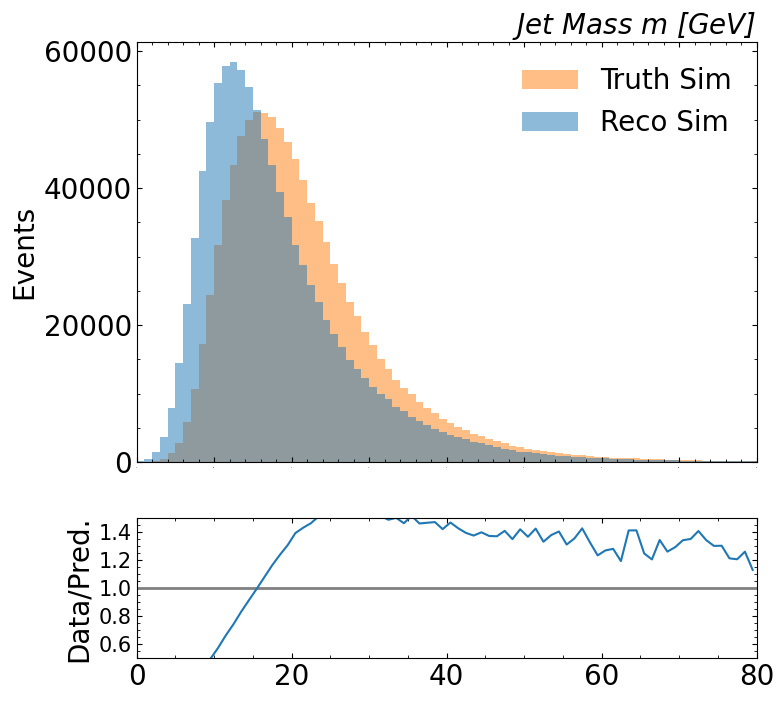

mult


<Figure size 640x480 with 0 Axes>

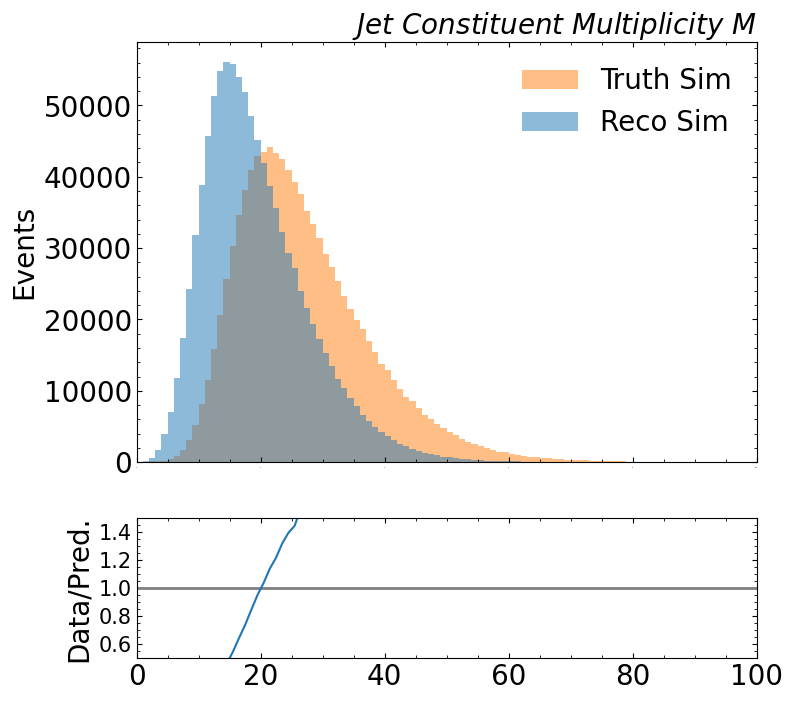

width


<Figure size 640x480 with 0 Axes>

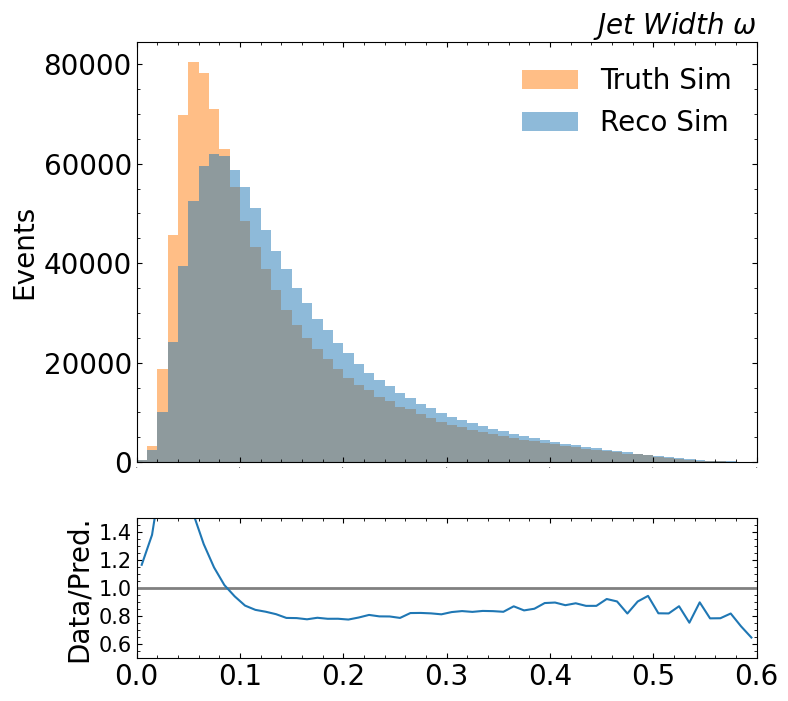

sdms


<Figure size 640x480 with 0 Axes>

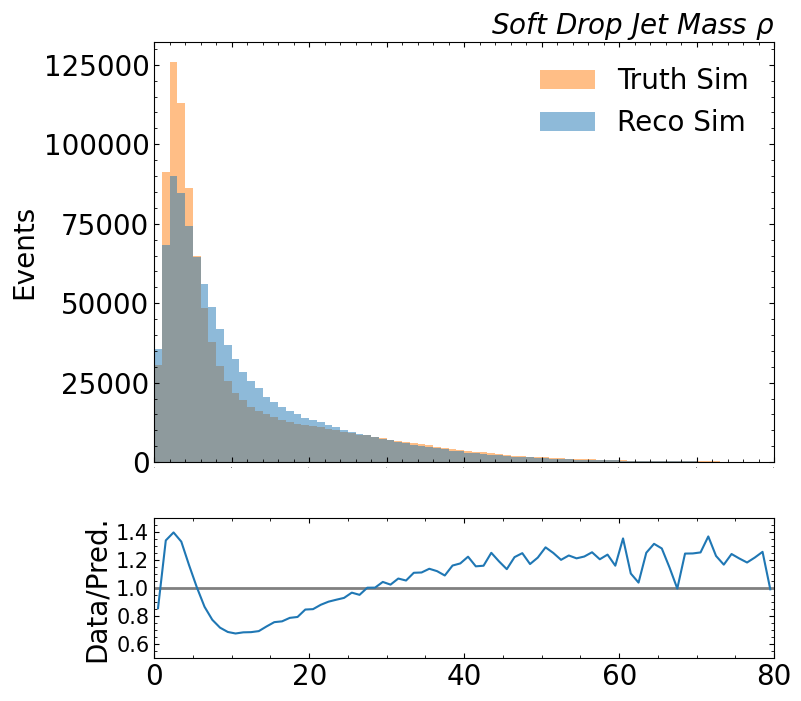

tau2s


<Figure size 640x480 with 0 Axes>

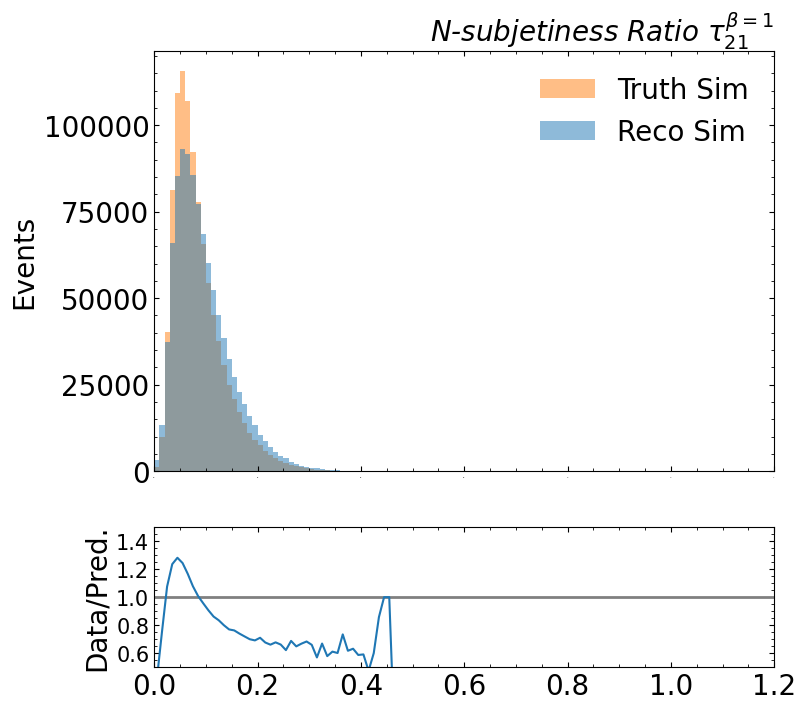

zgs


<Figure size 640x480 with 0 Axes>

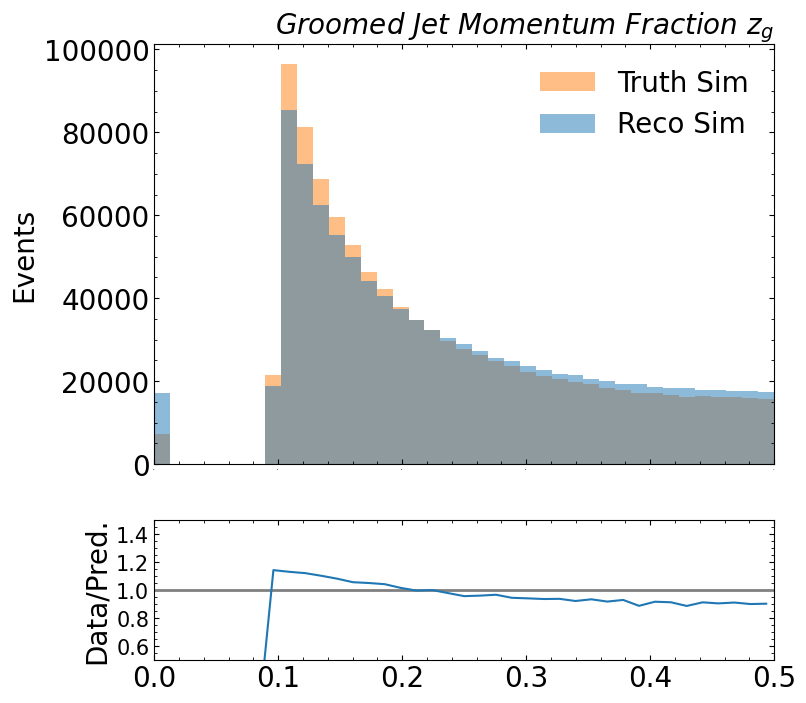

<Figure size 640x480 with 0 Axes>

In [128]:
b = { #simple plotting bins
    'mass'  : [0, 80, 81],
    'mult'  : [0,100, 101],
    'width' : [0, 0.6, 61],
    'sdms'  : [0, 80, 81],
    'tau2s' : [0, 1.2, 121],
    'zgs'   : [0, 0.5, 40]
}

for key, label in zip(T_sim_obs.keys(), labels):
                      
    T_sim = T_sim_obs[key]
    R_sim = R_sim_obs[key]
    print(key)
    

    cpwr = comparison_plots_with_ratio(b[key][0], b[key][1], b[key][2], xlabel=r"", density=False, legend_corner="upper right", header=label)
    cpwr.add_data(T_sim, label="Truth Sim", target=True, alpha=0.5, color='tab:orange')
    cpwr.add_data(R_sim, label="Reco Sim", alpha=0.5, color='tab:blue')
    #cpwr.add_data(T_data, label="Truth Data", target=True, alpha=0.5, color='tab:pink')
    #cpwr.add_data(R_data, label="Reco Data", alpha=0.5, color='tab:green')
    cpwr.show()

## Determine Binning for Response Matrix

In [83]:
# Binning Based on Purity

R_BinVals = {}

for key, label in zip(T_sim_obs.keys(), labels):
                      
    T_sim = T_sim_obs[key]
    R_sim = R_sim_obs[key]
    print()
    print()
    print(key)
    
    binvals = [min(min(T_sim), min(R_sim))]
    max_high = max(max(T_sim), max(R_sim))  #can also truncate to lower
    #might make sense to swap min and max, to ensure overlap of T and R, at cost of efficiency
    n_steps = 20

    i = 0

    # Find a more suitable initial step by looking at percentiles of data
    initial_step = np.percentile(T_sim, 10)  # Adjust this percentile based on your data distribution

    while binvals[-1] < max_high:
        print("Current bin boundaries:", binvals)
        # Adjust the number of points and the upper range in linspace dynamically
        for binhigh in np.linspace(binvals[-1] + initial_step, max_high+1, n_steps):
            mask = (T_sim > binvals[i]) & (T_sim < binhigh) & (R_sim > binvals[i]) & (R_sim < binhigh)
            total_range_mask = (T_sim > binvals[i]) & (T_sim < binhigh)
            total_in_range = total_range_mask.sum()
            if total_in_range > 0:
                purity = mask.sum() / total_in_range
            else:
                purity = 0

            print(f"Binhigh = {binhigh}, Purity = {purity}, Count in range = {total_in_range}")

            if purity > (0.5**0.5):
                print(f"Adding bin at {binhigh} with purity {purity}")
                i += 1
                binvals.append(binhigh)
                break
            elif binhigh >= max_high:
                binvals.append(max_high)
                break

        if total_in_range == 0 and binhigh > binvals[-1] + initial_step:
            print("No more data points available in the current range, widening search.")
            initial_step *= 2  # Double the step size to capture more data
            if initial_step > max_high - binvals[-1]:  # Ensure it doesn't exceed the max range
                initial_step = max_high - binvals[-1]
        elif total_in_range == 0:
            print("No more data points available, terminating loop.")
            break

    print("Final bin boundaries:", binvals)
    R_BinVals[key] = binvals



mass
Current bin boundaries: [-0.0003391435311641544]
Binhigh = 11.1495802709891, Purity = 0.7857800092012882, Count in range = 99986
Adding bin at 11.1495802709891 with purity 0.7857800092012882
Current bin boundaries: [-0.0003391435311641544, 11.1495802709891]
Binhigh = 22.299499685509364, Purity = 0.6704230235783634, Count in range = 519120
Binhigh = 35.94975859392005, Purity = 0.7918883561889208, Count in range = 809503
Adding bin at 35.94975859392005 with purity 0.7918883561889208
Current bin boundaries: [-0.0003391435311641544, 11.1495802709891, 35.94975859392005]
Binhigh = 47.099678008440314, Purity = 0.4478992148746756, Count in range = 60882
Binhigh = 59.44466437353885, Purity = 0.5753723932472691, Count in range = 80560
Binhigh = 71.78965073863739, Purity = 0.6077426503687801, Count in range = 86637
Binhigh = 84.13463710373591, Purity = 0.618985417487754, Count in range = 88805
Binhigh = 96.47962346883446, Purity = 0.6233585267429157, Count in range = 89706
Binhigh = 108.82

In [89]:
for key in R_BinVals.keys():
    print(key, R_BinVals[key])

mass [-0.0003391435311641544, 11.1495802709891, 35.94975859392005, 280.6544189453125]
mult [1, 16.0, 131]
width [0.0, 0.13247438355736324, 0.25797643113802315, 0.37687310779338523, 0.48951206462478086, 0.7087432935136241]
sdms [-5.151607069423487e-05, 16.537641440571054, 46.06323479611369, 280.65442474916097]
tau2s [0.0, 0.11128948827879842, 0.21672163506923903, 0.316604721502288, 0.45715932236550916]
zgs [0.0, 0.25792219620291285, 0.4999999046393872]


In [154]:
R_BinVals['mass'] = [0, 5, 9, 15, 30, 80]
R_BinVals['mult'] = [1, 6, 9, 15, 30, 50]
R_BinVals['sdms'] = [0, 5, 12, 25, 40, 50]
R_BinVals['tau2s']= [0, 0.05, 0.12, 0.2, 0.3, 0.46]
R_BinVals['zgs']  = [0, 0.1, 0.16, 0.3, 0.5]

In [156]:
from plotting import plot_response_matrix

mass
mult
width
sdms
tau2s
zgs


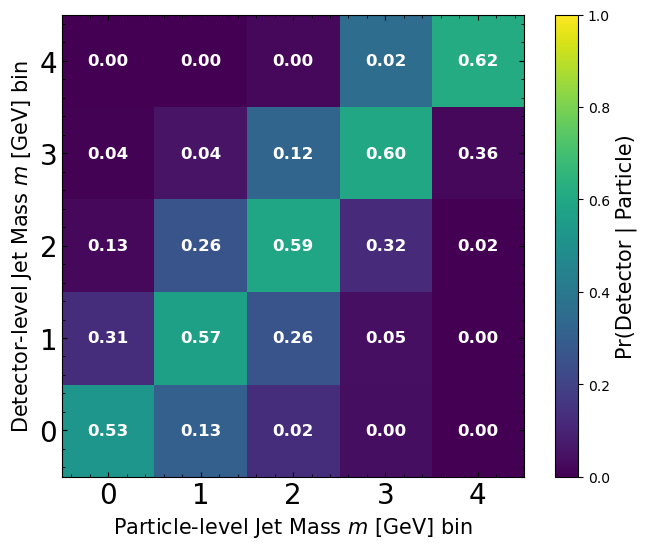

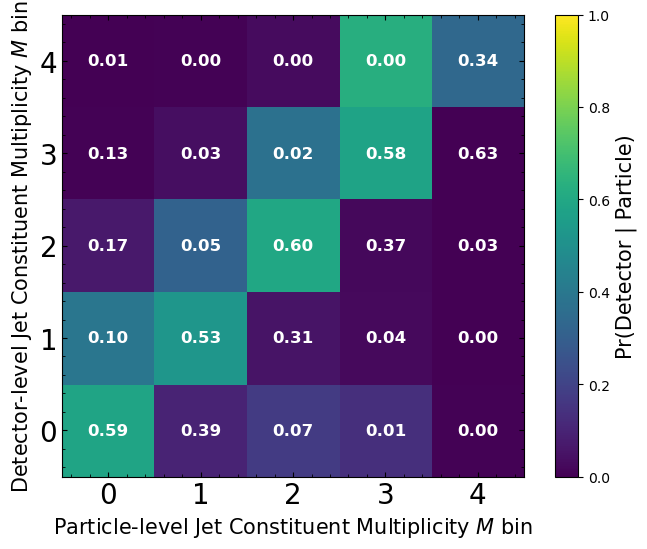

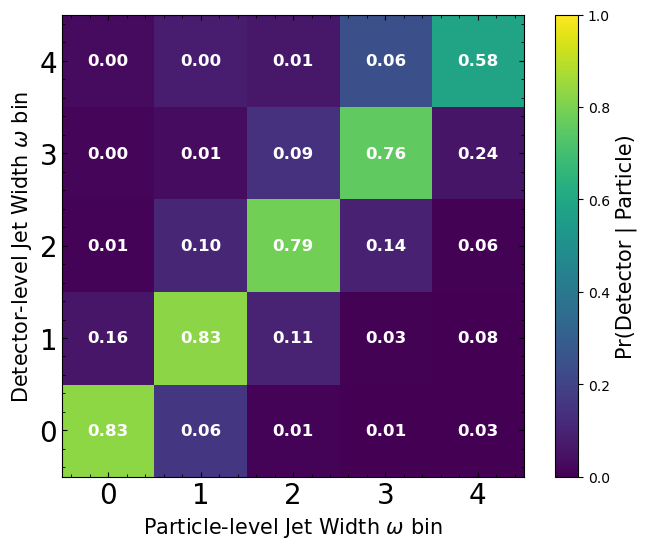

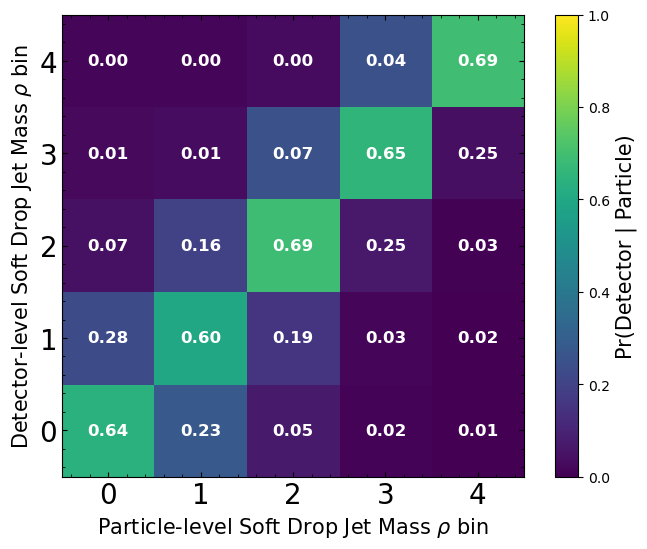

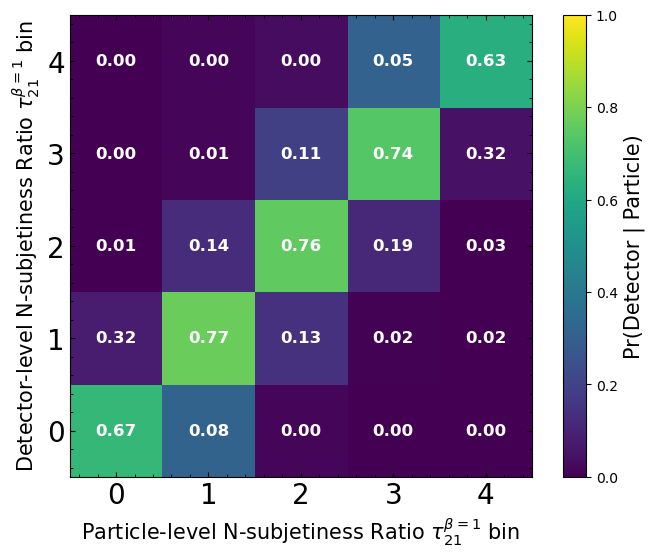

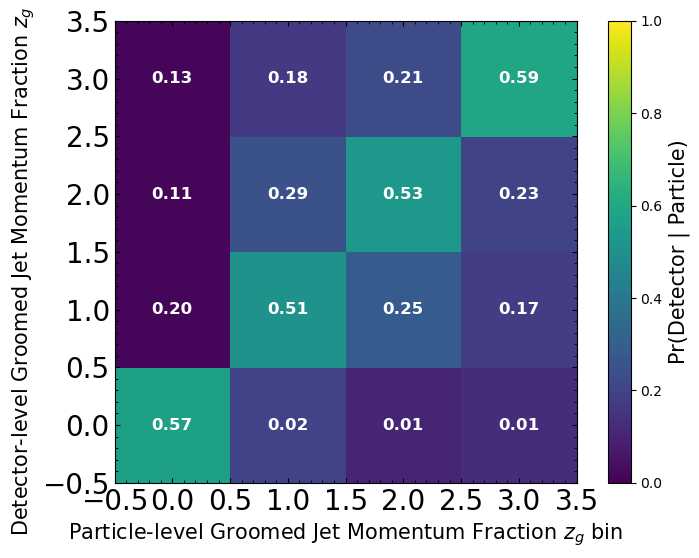

In [157]:
#Next, let's construct the response matrix.
H_pT_obs = {}
H_pT_data_obs = {}

for key, binvals, label in zip(T_sim_obs.keys(), R_BinVals, labels):
                      
    T_sim = T_sim_obs[key]
    R_sim = R_sim_obs[key]
    binvals = R_BinVals[key]
    print(key)
    
    wbin_truth = np.clip(np.digitize(T_sim,binvals),1,len(binvals)-1)-1
    wbin_reco = np.clip(np.digitize(R_sim,binvals),1,len(binvals)-1)-1
    H_pT, xedges, yedges = np.histogram2d(wbin_truth,wbin_reco,bins=[range(len(binvals)),range(len(binvals))])

    #data
    wbin_truth_data = np.clip(np.digitize(T_data,binvals),1,len(binvals)-1)-1
    wbin_reco_data = np.clip(np.digitize(R_data,binvals),1,len(binvals)-1)-1
    H_pT_data, _, _ = np.histogram2d(wbin_truth_data,wbin_reco_data,bins=[range(len(binvals)),range(len(binvals))])
    
    H_pT_obs[key] = H_pT
    H_pT_data_obs[key] = H_pT_data
    
    plot_response_matrix(H_pT, binvals, label)

In [158]:
def MLE(model,ymes,ndim):
    x = tf.Variable(ndim*[1.0/ndim])
    loss = lambda: -model.log_prob(x, bijector_kwargs={'conditional_input': ymes})
    losses = tfp.math.minimize(loss,
                               num_steps=10000,
                               #convergence_criterion=(
                               #     tfp.optimizers.convergence_criteria.LossNotDecreasing(atol=0.001)),
                               trainable_variables=[x],
                               optimizer=tf.optimizers.Adam(learning_rate=0.001))
    return x

def MADE(data_shape, cond_shape):
    # Density estimation with MADE.
    made = tfb.AutoregressiveNetwork(params=2,
                                     hidden_units=[50,50,50], #To be changed when using bigger histograms
                                     event_shape=data_shape,
                                     activation='swish',
                                     conditional=True,
                                     conditional_event_shape=cond_shape,
                                    )
    distribution = tfd.TransformedDistribution(
        distribution=tfd.Sample(tfd.Normal(loc=0., scale=1.), sample_shape=[data_shape]),
        bijector=tfb.MaskedAutoregressiveFlow(made))

    # Construct and fit model.
    x_ = tfkl.Input(shape=(data_shape,), dtype=tf.float32)
    c_ = tfkl.Input(shape=(cond_shape,), dtype=tf.float32)
    log_prob_ = distribution.log_prob(x_, bijector_kwargs={'conditional_input': c_})
    model = tfk.Model([x_,c_], log_prob_)

    model.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4),loss=lambda _, log_prob: -log_prob)
    return model, distribution

def NPU(ymes,Rin,N):
    #Inputs: 
    # ymes: Measured data provided in a histogram with N bins (N,)
    # Rin: Detector resolution matrix. First coordinate is the measured value and second coordinate is the truth level. (M,M)
    # N: Total number of observations
    #Returns samples from p(true|measured).  Would normally want the mode over true, which is equivalent to the MLE given p(true) is uniform.

    M = 1000000 # a big number - should make bigger later

    ts = np.random.uniform(0,1,(M,len(ymes)) ) # M values with len(ymes) bins
    ts=N*ts/np.sum(ts,-1,keepdims=True)
    print(np.sum(ts,-1))

    ms = []
    for j in range(len(ts)):
        if j % 100000 == 0: print(f"{j}/{len(ts)}")
        m_hold = [np.random.poisson(ts[j][i]) for i in range(len(ts[j]))] #stat fluctuations
        m_holds = np.random.multinomial(m_hold[0],Rin[:,0])
        for i in range(1, len(ts[j])):
            m_holds += np.random.multinomial(m_hold[i],Rin[:,i])
        ms += [m_holds]
        pass
    ts = np.array(ts)
    ms = np.array(ms)

    n = len(ts)
    x = ms #conditional feature
    y = ts #learn p(y|x)
    nx = N
    ny = N

    #Normalize the total number of events to make the NF easier to train
    x = x/float(nx)
    y = y/float(ny)

    model,dist = MADE(y.shape[1],x.shape[1])
    # Fit.
    batch_size = 10000
    myhistory = model.fit([y,x],
                          y=np.zeros((len(x),0), dtype=np.float32), #dummy labels
                          batch_size=batch_size,
                          epochs=800,
                          verbose = 1)

    plt.plot(myhistory.history['loss'][10:-1])
    plt.xlabel("epochs")
    plt.ylabel("loss")

    # mle = MLE(dist,ymes/float(nx),y.shape[-1])
    # print(mle)
    nsample = 1000
    mle = MLE(dist,ymes/float(nx),y.shape[-1]).numpy()
    output = dist.sample(nsample, bijector_kwargs={'conditional_input': np.tile(ymes/float(nx),nsample).reshape([nsample,len(ymes)])}).numpy()
    return output*ny,mle*ny

In [159]:
# def IBU(ymes,t0,Rin,n):
#     #This is the iterative Bayesian unfolding method.
#     #Rin is a matrix where the first coordinate is the measured value and the second coordinate is the true value.
#     #n is the number of iterations.

#     tn = t0
#     for i in range(n):
#         Rjitni = [np.array(Rin[:][i])*tn[i] for i in range(len(tn))]
#         Pm_given_t = Rjitni / np.matmul(Rin,tn)
#         tn = np.dot(Pm_given_t,ymes)
#         pass
#     return tn

def IBU(data, init, r, det_binwidth=1, mc_binwidth=1, it=10):
    
    # initialize the truth distribution to the prior
    phis = [init]
    
    # iterate the procedure
    for i in range(it):
        
        # update the estimate for the matrix m
        m = r * phis[-1]
        m /= (m.sum(axis=1)[:,np.newaxis] + 10**-50)

        # update the estimate for the truth distribution
        # the factors of binwidth show up here to change probabilities into probability densities
        phis.append(np.dot(m.T, data)*det_binwidth/mc_binwidth)
        
    return phis

In [161]:
IBU_obs = {}
D_data_obs = {}
H_norm_pT_obs = {}
for key, binvals, label in zip(T_sim_obs.keys(), R_BinVals, labels):
                      
    H_pT = H_pT_obs[key]
    H_pT_data = H_pT_data_obs[key]
    H_norm_pT = H_pT / H_pT.sum(axis=1, keepdims=True)
    print(key)

    T_mc = np.sum(H_pT,axis=1)
    D_mc = np.sum(H_pT,axis=0)
    IBU(T_mc,D_mc,H_norm_pT.T,5)-T_mc

    T_data = np.sum(H_pT_data,axis=1)
    D_data = np.sum(H_pT_data,axis=0)

    #ibu = (IBU(T_mc, D_data, H_norm_pT.T, 5)-T_data)/T_data
    ibu = IBU(D_data, T_mc, H_norm_pT.T, 1, 1, 10)[10]
    print(ibu)
    
    IBU_obs[key] = ibu
    D_data_obs[key] = D_data
    H_norm_pT_obs[key] = H_norm_pT

mass
[9.99985590e+05 1.44103197e+01 2.47833083e-06 4.38552533e-13
 9.95335431e-25]
mult
[8.99863468e+05 1.00136502e+05 3.04281042e-02 9.42635074e-11
 1.00711265e-22]
width
[553794.9508808  287905.42775623 108239.33913351  42302.30654209
   7757.97568736]
sdms
[9.99978691e+05 2.13090264e+01 1.31967636e-06 1.02973043e-09
 9.99282367e-13]
tau2s
[ 55987.56249904 387329.04948801 254024.31352653 119661.80733915
 182997.26714728]
zgs
[532169.22747857 191119.92518411 247038.58039879  29672.26693853]


In [ ]:
NPU_obs = {}
MLE_obs = {}

for key, binvals, label in zip(T_sim_obs.keys(), R_BinVals, labels):
    
    D_data = D_data_obs[key]
    H_norm_pT = H_norm_pT_obs[key]
    
    N = D_data.sum()
    print(key, N)

    npu, mle = NPU(D_data, H_norm_pT.T, N)
    NPU_obs[key] = npu
    MLE_obs[key] = mle

mass 1000000.0
[1000000. 1000000. 1000000. ... 1000000. 1000000. 1000000.]
0/1000000
100000/1000000
200000/1000000
300000/1000000
400000/1000000
500000/1000000
600000/1000000
700000/1000000
800000/1000000
900000/1000000
Epoch 1/800
100/100 [==============================] - 1s 5ms/step - loss: 4.9971
Epoch 2/800
100/100 [==============================] - 0s 3ms/step - loss: 4.5085
Epoch 3/800
100/100 [==============================] - 0s 3ms/step - loss: 3.7708
Epoch 4/800
100/100 [==============================] - 0s 4ms/step - loss: 2.5810
Epoch 5/800
100/100 [==============================] - 0s 4ms/step - loss: 0.7918
Epoch 6/800
100/100 [==============================] - 0s 4ms/step - loss: -1.3227
Epoch 7/800
100/100 [==============================] - 0s 4ms/step - loss: -3.8028
Epoch 8/800
100/100 [==============================] - 0s 4ms/step - loss: -5.3267
Epoch 9/800
100/100 [==============================] - 0s 4ms/step - loss: -6.0291
Epoch 10/800
100/100 [================

In [ ]:
# plt.scatter(list(0.5*(bins[1:]+bins[:-1]))*1000,npu.reshape(-1), marker='*', label="NPU",s=40)
# train stat = 10000
#plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_result_mode, label='FBU mode', xerr=0, yerr=fbu_sigma, marker='o', linestyle='None')
#plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_result_mean, label='FBU mean', xerr=0, yerr=fbu_sigma, marker='o', linestyle='None', color='tab:orange')
plt.scatter(0.5*(bins[1:]+bins[:-1]), T_data, color='black', label='Truth data')
plt.scatter(0.5*(bins[1:]+bins[:-1]), D_data, color='tab:blue', label='Observed data')
plt.fill_between(bins, np.insert(ibu, len(ibu), np.array(ibu[-1])), step='post', alpha=0.3, color='tab:blue', label='IBU')
plt.fill_between(bins, np.insert(mle, len(mle), np.array(mle[-1])), step='post', alpha=0.3, color='tab:orange', label='NPU (MLE)')
plt.legend(frameon=False, loc="upper right")
plt.xlim(0,30)
plt.show()
plt.clf()

In [ ]:
!python -m pip install corner

In [ ]:
import corner

In [ ]:
np.savez_compressed("npu_gaussian_100000.npz", **{"bins": bins, "npu": npu, "mle": mle})

In [ ]:
aaa=np.load("npu_gaussian_100000.npz")

In [ ]:
list(aaa.keys())

In [ ]:
figure = corner.corner(
    npu,
#     labels=[
#         r"Bin Index",
#         r"Bin Index",
#         r"$\log \alpha$",
#         r"$\Gamma \, [\mathrm{parsec}]$",
#     ],
#     quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)